# Strategy

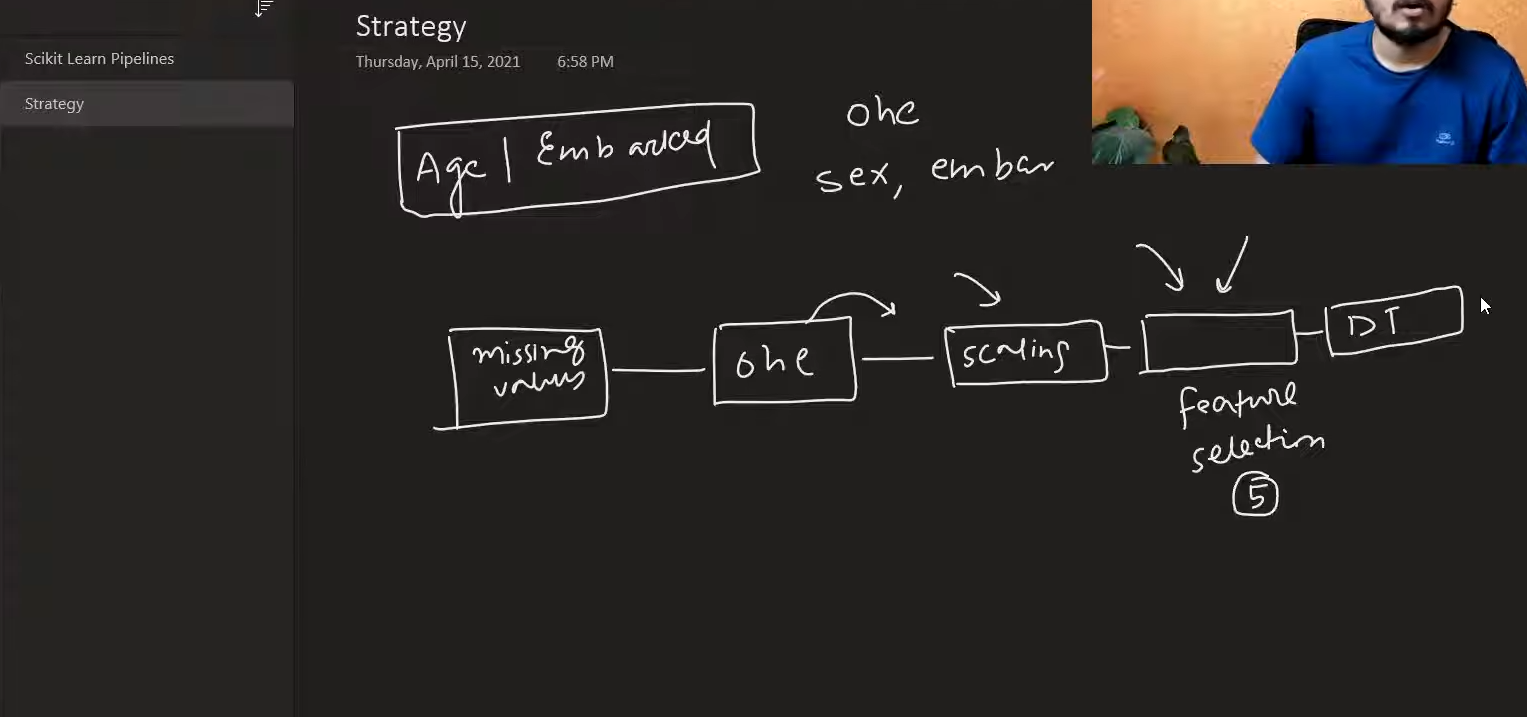



in step 1 (missing values)  = we will fix missing values using (imputer)

in step 2 ( OneHotEncoding) = then we will send input of step 1 in step 2 and do OHE on (sex, embarked)

in step 3 (Scaling)  = then we will do scaling on ouptut of step 2

in step 4 (feature selection) = we will use feature selection

step 5 = we will train our model 

In [55]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline , make_pipeline
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

In [56]:
df = pd.read_csv('titanic.csv')

In [57]:
# url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
# df = pd.read_csv(url)

In [58]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Let's plan

In [59]:
df.drop(columns = ['PassengerId' ,'Name' ,'Ticket','Cabin'],inplace = True)

In [60]:
x_train, x_test, y_train, y_test = train_test_split(df.drop(columns = ['Survived']),df['Survived'],test_size = 0.2,
                                                    random_state = 42)

In [61]:
x_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,1,male,45.5,0,0,28.5000,S
733,2,male,23.0,0,0,13.0000,S
382,3,male,32.0,0,0,7.9250,S
704,3,male,26.0,1,0,7.8542,S
813,3,female,6.0,4,2,31.2750,S


In [62]:
y_train.head()

331    0
733    0
382    0
704    0
813    0
Name: Survived, dtype: int64

In [63]:
 # imputation
 trf1 = ColumnTransformer([
    ('impute_age', SimpleImputer(),[2]),
    ('impute_embarked', SimpleImputer(strategy = 'most_frequent'),[6])
 ],remainder = 'passthrough')

 # summary = here we are taking index number instead of name coz after column transfer when it will go 
 # in next step it will be a numpy  array rather than data that we would be getting if had used column name

In [64]:
# onehotEncoding
trf2 = ColumnTransformer([
    ('ohe_sex_embarked', OneHotEncoder(sparse_output = False, handle_unknown = 'ignore'),[1,6])
],remainder = 'passthrough')

In [65]:
# Scaling
trf3 = ColumnTransformer([
    ('scale', MinMaxScaler(), slice(0,10))
])


# in standard pandas datataframe we keep columns names and create new columns of their categories
# but in sickit learn pipelines we create columns of categories but don't keep the columns names

In [66]:
# feature selection
trf4 = SelectKBest(score_func = chi2,k = 8)

In [67]:
# train this model 
trf5 = DecisionTreeClassifier()

# Create a PipeLine

In [68]:
pipe = Pipeline([
    ('trf1',trf1),
    ('trf2',trf2),
    ('trf3',trf3),
    ('trf4',trf4),
    ('trf5',trf5)
])

# Pipeline vs make_pipeline
pipeline requires naming of steps , make_pipeline does not

(same applies to columnTransformer vs make_column_transformer)

In [69]:
# Alternative syntax
# pipe = make_pipeline(trf1,trf2,trf3,trf4,trf5)

In [70]:
# train

pipe.fit(x_train,y_train)

,steps,"[('trf1', ...), ('trf2', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('impute_age', ...), ('impute_embarked', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Explore the pipeline

In [71]:
# code 
pipe.named_steps['trf1'].transformers_[1][1].statistics_

array(['S'], dtype=object)

In [72]:
# Display Pipeline

from  sklearn import set_config
set_config(display = 'diagram')

In [73]:
# predict
y_pred = pipe.predict(x_test)

In [74]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.6256983240223464

#  Cross validation using pipline

In [75]:

from sklearn.model_selection import cross_val_score
cross_val_score(pipe, x_train, y_train, cv = 5, scoring = 'accuracy').mean()

# here cv value is 5 so we train_test_split 5 different times and run algorith everytime and calulate
# mean score of accuracy and accept it as our actual score

np.float64(0.6391214419383433)

# GridSearch using pipeline
in any algorithm we can change ita settings and improve its performance 

In [76]:
params = {
    'trf5__max_depth':[1,2,3,4,5,None]
}

In [77]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(pipe, params,cv=5,scoring = 'accuracy')
grid.fit(x_train,y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'trf5__max_depth': [1, 2, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('impute_age', ...), ('impute_embarked', ...)]"


In [78]:
grid.best_score_

np.float64(0.6391214419383433)

In [79]:
grid.best_params_

{'trf5__max_depth': 2}

# Exporting the pipeline

In [80]:
import pickle 
pickle.dump(pipe,open('pipe.pkl','wb'))

# we don't need to bring ohe and object spearately they are in pipe lne